# LVL. 5

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
bios = pd.read_csv('datasets/bios.csv')
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


## What is the average lifespan of athletes?

In [3]:
bios['born_datetime'] = pd.to_datetime(bios['born_date'])
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,born_datetime
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,1886-12-12
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,1969-04-01
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,1898-08-13
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,1895-05-11
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,1878-04-17


In [4]:
# bios['born_year'] = bios['born_datetime'].dt.year()
bios.insert(2,'born_year', bios['born_datetime'].dt.year)
bios.head()

,athlete_id,name,born_year,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,born_datetime
0,1,Jean-François Blanchy,1886.0,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,1886-12-12
1,2,Arnaud Boetsch,1969.0,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,1969-04-01
2,3,Jean Borotra,1898.0,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,1898-08-13
3,4,Jacques Brugnon,1895.0,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,1895-05-11
4,5,Albert Canet,1878.0,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,1878-04-17


In [8]:
print(bios['born_year'].min())
print(bios['born_year'].max())

1828.0
2009.0


In [11]:
bios['died_date'].isna().sum()

np.int64(111560)

In [13]:
# 111560 have missing died_date, hence we dont have their total lifespan
# hence wel will calculate the avg life span of deceased athletes 🙏
deceased = bios[bios['died_date'].notna()]
deceased.head()


,athlete_id,name,born_year,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,born_datetime
0,1,Jean-François Blanchy,1886.0,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,1886-12-12
2,3,Jean Borotra,1898.0,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,1898-08-13
3,4,Jacques Brugnon,1895.0,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,1895-05-11
4,5,Albert Canet,1878.0,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,1878-04-17
7,8,Henri Cochet,1901.0,1901-12-14,Villeurbanne,Rhône,FRA,France,NaN,NaN,1987-04-02,1901-12-14


In [14]:
# determining death year
deceased['died_date_datetime'] = pd.to_datetime(deceased['died_date'])

deceased.insert(3, 'died_year', deceased['died_date_datetime'].dt.year)
deceased.head()

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/3566925591.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['died_date_datetime'] = pd.to_datetime(deceased['died_date'])


,athlete_id,name,born_year,died_year,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,born_datetime,died_date_datetime
0,1,Jean-François Blanchy,1886.0,1960,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,1886-12-12,1960-10-02
2,3,Jean Borotra,1898.0,1994,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,1898-08-13,1994-07-17
3,4,Jacques Brugnon,1895.0,1978,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,1895-05-11,1978-03-20
4,5,Albert Canet,1878.0,1930,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,1878-04-17,1930-07-25
7,8,Henri Cochet,1901.0,1987,1901-12-14,Villeurbanne,Rhône,FRA,France,NaN,NaN,1987-04-02,1901-12-14,1987-04-02


In [18]:
time_difference = deceased['died_date_datetime'] - deceased['born_datetime']
life_span_yrs = time_difference.dt.days / 365.25
deceased.insert(3, 'life_span_yrs', life_span_yrs)
deceased.head() 


,athlete_id,name,born_year,life_span_yrs,died_year,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,born_datetime,died_date_datetime
0,1,Jean-François Blanchy,1886.0,73.804244,1960,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,1886-12-12,1960-10-02
2,3,Jean Borotra,1898.0,95.923340,1994,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,1898-08-13,1994-07-17
3,4,Jacques Brugnon,1895.0,82.855578,1978,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,1895-05-11,1978-03-20
4,5,Albert Canet,1878.0,52.268309,1930,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,1878-04-17,1930-07-25
7,8,Henri Cochet,1901.0,85.297741,1987,1901-12-14,Villeurbanne,Rhône,FRA,France,NaN,NaN,1987-04-02,1901-12-14,1987-04-02


In [ ]:
# average life-span
deceased['life_span_yrs'].mean()
# 71.4264177929806

np.float64(71.4264177929806)

## Has athlete lifespan increased over time?

In [ ]:
decade = (bios['born_year'] // 10) * 10
deceased.insert(5, 'decade', decade)
deceased.head()

,athlete_id,name,born_year,life_span_yrs,died_year,decade,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,born_datetime,died_date_datetime
0,1,Jean-François Blanchy,1886.0,73.804244,1960,1880.0,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,1886-12-12,1960-10-02
2,3,Jean Borotra,1898.0,95.923340,1994,1890.0,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,1898-08-13,1994-07-17
3,4,Jacques Brugnon,1895.0,82.855578,1978,1890.0,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,1895-05-11,1978-03-20
4,5,Albert Canet,1878.0,52.268309,1930,1870.0,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,1878-04-17,1930-07-25
7,8,Henri Cochet,1901.0,85.297741,1987,1900.0,1901-12-14,Villeurbanne,Rhône,FRA,France,NaN,NaN,1987-04-02,1901-12-14,1987-04-02


In [35]:
deceased['life_span_yrs'].interpolate(inplace = True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/1743864911.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deceased['life_span_yrs'].interpolate(inplace = True)
/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/1743864911.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['life_span_yrs'].interpola

In [40]:
median_value = deceased['decade'].median()
deceased['decade'].fillna(median_value, inplace=True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/490751254.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['decade'].fillna(median_value, inplace=True)


<Axes: xlabel='decade'>

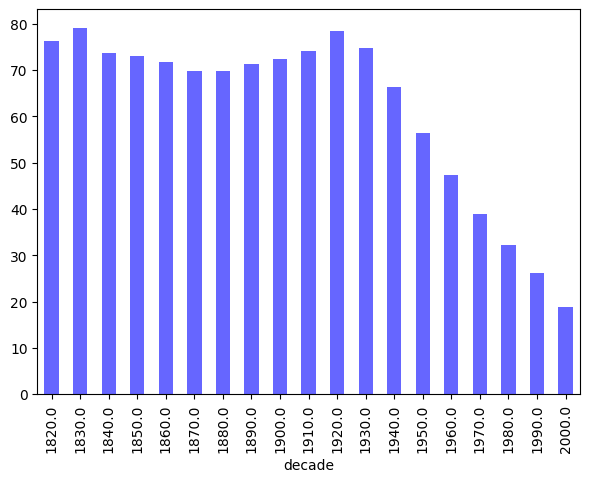

In [47]:
# average lifespan by decade
life_by_Decade = deceased.groupby('decade')['life_span_yrs'].mean()
# life_by_Decade
plt.figure(figsize = (7,5))
life_by_Decade.plot(kind = 'bar', color = 'blue', alpha = 0.6)

## Compare lifespan of athletes born before vs after 1940.

In [55]:
deceased_before_40s = deceased[deceased['born_year'] < 1940]
deceased_after_40s = deceased[deceased['born_year'] >= 1940]

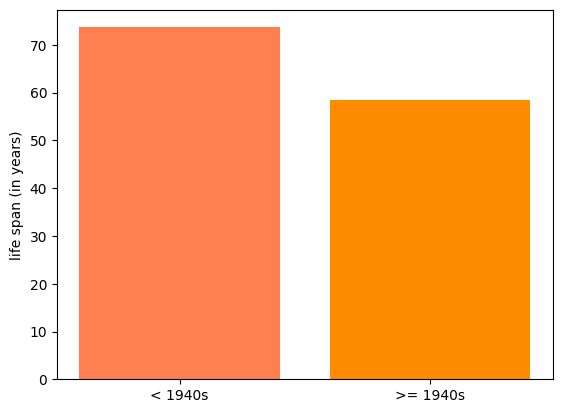

In [ ]:
# deceased_before_40s['life_span_yrs'].mean()
# deceased_after_40s['life_span_yrs'].mean()
data = {
    '< 1940s':deceased_before_40s['life_span_yrs'].mean(),
    '>= 1940s':deceased_after_40s['life_span_yrs'].mean()
}
plt.bar(data.keys(), data.values(), color = ['coral','darkorange'])
plt.ylabel('life span (in years)')
plt.show()
# before was the more lifespan

## Is there a relationship between physical build and longevity?

In [ ]:
# from physical build and longetivity
# we'll calculate BMI

# deceased['BMI'] = (deceased['weight_kg'] * 10000) / (deceased['height_cm']**2)
# deceased['BMI']

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/91673493.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['BMI'] = (deceased['weight_kg'] * 10000) / (deceased['height_cm']**2)


0               NaN
2         22.694019
3         22.675737
4               NaN
7               NaN
            ...    
145435          NaN
145492          NaN
145494          NaN
145498          NaN
145499          NaN
Name: BMI, Length: 33940, dtype: float64

In [66]:
deceased['weight_kg'].interpolate(inplace = True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/4111250952.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deceased['weight_kg'].interpolate(inplace = True)
/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/4111250952.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['weight_kg'].interpolate(inpla

In [69]:
weight_mean = deceased['weight_kg'].mean()
deceased['weight_kg'].fillna(weight_mean, inplace = True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/754453544.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deceased['weight_kg'].fillna(weight_mean, inplace = True)
/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/754453544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['weight_kg'].fillna(weig

In [71]:
deceased['height_cm'].interpolate(inplace = True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/2553856939.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deceased['height_cm'].interpolate(inplace = True)
/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/2553856939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['height_cm'].interpolate(inpla

In [72]:
height_mean = deceased['height_cm'].mean()
deceased['height_cm'].fillna(height_mean, inplace = True)

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/2509260310.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deceased['height_cm'].fillna(height_mean, inplace = True)
/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/2509260310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['height_cm'].fillna(he

In [73]:
deceased['BMI'].isna().sum()

np.int64(21600)

In [74]:
deceased['BMI'] = (deceased['weight_kg'] * 10000) / (deceased['height_cm']**2)
deceased['BMI']

/var/folders/c9/p4s2n3nx6zxffbhgf6dtds_h0000gn/T/ipykernel_17345/2704270985.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deceased['BMI'] = (deceased['weight_kg'] * 10000) / (deceased['height_cm']**2)


0         23.841170
2         22.694019
3         22.675737
4         22.653104
7         22.630513
            ...    
145435    23.888441
145492    23.888441
145494    23.888441
145498    29.031790
145499    29.031790
Name: BMI, Length: 33940, dtype: float64

In [77]:
deceased[['BMI', 'life_span_yrs']]

,BMI,life_span_yrs
0,23.841170,73.804244
2,22.694019,95.923340
3,22.675737,82.855578
4,22.653104,52.268309
7,22.630513,85.297741
...,...,...
145435,23.888441,24.536619
145492,23.888441,92.585900
145494,23.888441,82.521561
145498,29.031790,86.828200


In [78]:
# well do linear regression
x = deceased['BMI'].values
y = deceased['life_span_yrs'].values

x = (np.mean(x) - x) / (np.std(x))
y = (np.mean(y) - y) / (np.std(y))

In [79]:
# m
num = np.sum((x - np.mean(x))*(y - np.mean(y)))
den = np.sum((x - np.mean(x))**2)

m = num/den
m

np.float64(-0.02205549303373907)

In [80]:
b = np.mean(y) - m * np.mean(x)
b

np.float64(4.128829279197375e-16)

In [81]:
y_pred = m*x + b

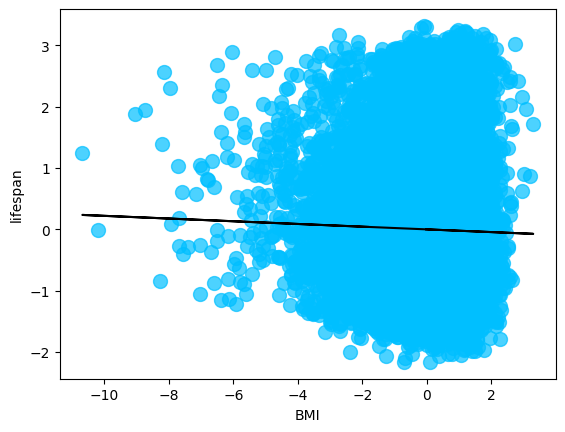

In [ ]:
plt.scatter(x,y,color = 'deepskyblue', alpha = 0.7, label= 'actual data points', s = 100)
plt.plot(x,y_pred, color = 'black', label = 'predicted points')
plt.xlabel('BMI')
plt.ylabel('lifespan')
plt.show()
# AS BMI increases, lifespan declines

In [84]:
# coeff of correlation
pearson_coef = np.corrcoef(x,y)[0,1]
pearson_coef

np.float64(-0.02205549303373907)